In [ ]:

import numpy as np
import iris
import time
#matplotlib.use('Agg')
import warnings
import os
import glob
import sys
import iris.coord_categorisation as icc
sys.path.insert(0, '/data/users/bob.potts/StateOfFires_2025-26/code')
import re
import pandas as pd
from utils.constrain_cubes_standard import *
from utils.cubefuncs import *
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
import seaborn as sns



############# User inputs here #############
Country = 'South'
member = 10
# Options: 'South Korea' (3), 'Iberia' (8), 'Scotland' (7)
############# User inputs end here #############


folder = '/data/scratch/chantelle.burton/SoW2526/'

#Set up the 2025 files and months automatically
if Country == 'South Korea':
    print('Running South Korea')
    Month = 3
    month = 'March'
    percentile = 95
    shape_name = 'Southeast South Korea'
    daterange = iris.Constraint(time=lambda cell: cell.point.month == Month)
    ERA5_2025 = iris.load_cube(folder+'Y2526FWI/FWI_ERA5_std_reanalysis_2025-01-01-2025-05-01_global_day_initialise-from=previous-and-use-numpy=False-and-code-src=copernicus-and-save-input-data=True.nc', 'canadian_fire_weather_index')
      
elif Country == 'Iberia':
    print('Running Iberia')
    Month = 8
    month = 'Aug'
    percentile = 95
    shape_name = 'Northwest Iberia'
    daterange = iris.Constraint(time=lambda cell: cell.point.month == Month)
    ERA5_2025 = iris.load_cube(folder+'Y2526FWI/FWI_ERA5_std_reanalysis_2025-06-01-2025-10-01_global_day_initialise-from=previous-and-use-numpy=False-and-code-src=copernicus-and-save-input-data=True.nc', 'canadian_fire_weather_index')

elif Country == 'Scotland':
    print('Running Scotland')
    Month = 7
    month = 'July'
    percentile = 95
    shape_name = 'Scottish Highlands'
    daterange = iris.Constraint(time=lambda cell: cell.point.month == Month)
    ERA5_2025 = iris.load_cube(folder+'Y2526FWI/FWI_ERA5_std_reanalysis_2025-06-01-2025-10-01_global_day_initialise-from=previous-and-use-numpy=False-and-code-src=copernicus-and-save-input-data=True.nc', 'canadian_fire_weather_index')

Running South Korea


12.769921874999998


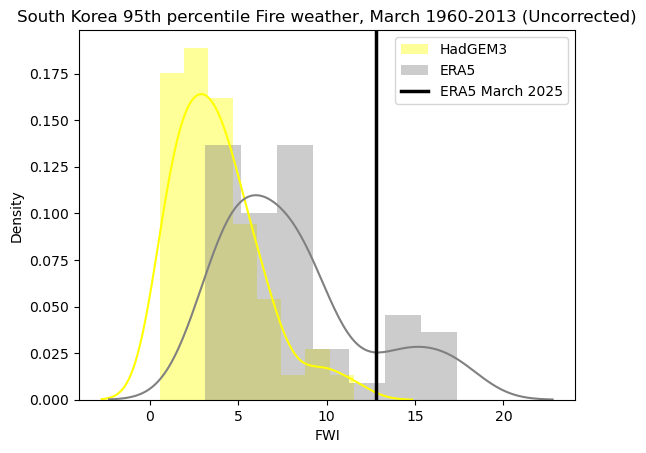

In [8]:
ERA5_2025 = ERA5_2025.extract(daterange)
#Get the ERA5 2025 data for the threshold line
ERA5_2025 = contrain_to_sow_shapefile(ERA5_2025, '/data/users/chantelle.burton/Attribution/StateOfFires_2025-26/SoW2526_Focal_MASTER_20260218.shp', shape_name)
ERA5_2025 = CountryPercentile(ERA5_2025, percentile)
ERA5_2025 = TimePercentile(ERA5_2025, percentile)
ERA5_2025 = np.array(ERA5_2025.data)
print(ERA5_2025)
#this is the era5 95% for 2025 for the threshold line

##Make the plot

HadGEM3_Arr = pd.read_csv(f'/data/scratch/bob.potts/sowf/test_output/Baseline/HadGEM3_FWI_1960-2013_{Country}_{member}_95%.dat', header=None).values.flatten()
ERA5_ImpactsToolBox_Arr = pd.read_csv(f'/data/scratch/bob.potts/sowf/test_output/Baseline/ERA5_FWI_1960-2013_{Country}95%.dat', header=None).values.flatten()

##Make the plot
import seaborn as sns
sns.distplot(HadGEM3_Arr, hist=True, kde=True, 
             color = 'yellow', fit_kws={"linewidth":2.5,"color":"orange"}, label='HadGEM3')

sns.distplot(ERA5_ImpactsToolBox_Arr, hist=True, kde=True, 
             color = 'grey', fit_kws={"linewidth":2.5,"color":"black"}, label='ERA5')

plt.axvline(x=ERA5_2025, color='black', linewidth=2.5, label='ERA5 '+month+' 2025')


plt.xlabel('FWI')
plt.title(f'{Country} {percentile}th percentile Fire weather, {month} 1960-2013 (Uncorrected)')
plt.legend(loc='best')
plt.show()
